# Health Insurance Premium Prediction

## Objective

The objective of this project is to analyze the factors affecting health insurance charges and build a machine learning model to predict insurance premiums based on customer information.

## Data Import and Exploration

Import the necessary libraries and explore the dataset to understand its structure and contents.

In [120]:
import pandas as pd
df= pd.read_csv("../data/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [121]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [122]:
%matplotlib inline

In [123]:
df.shape

(1338, 7)

In [124]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [125]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [126]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [127]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [128]:
# Observations:
# • No missing values are present in the dataset.
# • The dataset is complete and does not require missing value imputation.

In [129]:
df["charges"].describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

In [130]:
df.sample(10)

,age,sex,bmi,children,smoker,region,charges
1130,39,female,23.870,5,no,southeast,8582.30230
209,40,male,41.230,1,no,northeast,6610.10970
1235,26,male,31.065,0,no,northwest,2699.56835
905,26,female,29.355,2,no,northeast,4564.19145
338,50,male,32.300,1,yes,northeast,41919.09700
624,59,male,28.785,0,no,northwest,12129.61415
1042,20,male,30.685,0,yes,northeast,33475.81715
495,20,male,27.930,0,no,northeast,1967.02270
1156,19,male,44.880,0,yes,southeast,39722.74620
331,52,male,27.360,0,yes,northwest,24393.62240


In [131]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [132]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [133]:
df.duplicated().sum()

np.int64(1)

In [134]:
# Observations:
# • No duplicate records are present in the dataset.
# • Each observation represents a unique policyholder.

## Exploratory Data Analysis

Visualize the data to identify distributions, relationships, and patterns that influence insurance charges.

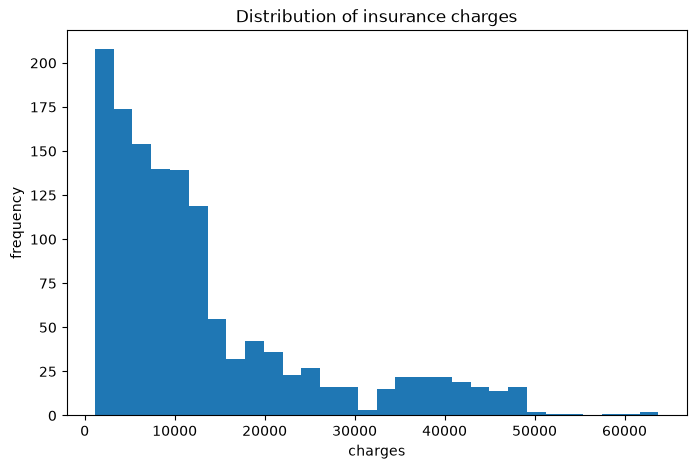

In [135]:
#distribution of insurance charges
plt.figure(figsize=(8,5))
plt.hist(df["charges"], bins=30)
plt.title("Distribution of insurance charges")
plt.xlabel("charges")
plt.ylabel("frequency")
plt.show()

In [136]:
# Observations:
# • Insurance charges are positively (right) skewed.
# • Most policyholders have relatively low insurance charges.
# • A small number of individuals incur exceptionally high charges.
# • The presence of high-value observations suggests possible outliers.

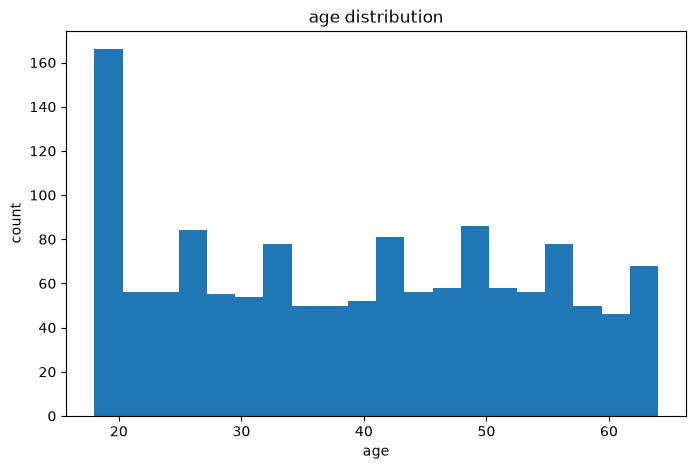

In [137]:
#age distribution
plt.figure(figsize=(8,5))
plt.hist(df["age"], bins=20)
plt.title("age distribution")
plt.xlabel("age")
plt.ylabel("count")
plt.show()

In [138]:
# Observations:
# • The age distribution is fairly uniform.
# • Most policyholders are between 20 and 60 years of age.
# • No significant outliers are visible.

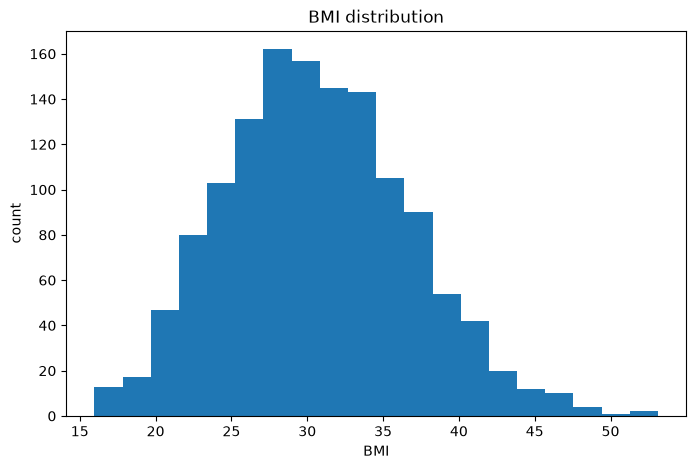

In [139]:
#BMI distribution
plt.figure(figsize=(8,5))
plt.hist(df["bmi"], bins=20)
plt.title("BMI distribution")
plt.xlabel("BMI")
plt.ylabel("count")
plt.show()

In [140]:
# Observations:
# • BMI values are concentrated around the middle range.
# • The distribution appears approximately normal with a slight right skew.
# • A small number of individuals have relatively high BMI values.
# • No major anomalies are observed.

In [141]:
df["sex"].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [142]:
# Observations:
# • The dataset contains both male and female policyholders.
# • The distribution is nearly balanced, reducing the likelihood of gender bias in the analysis.

In [143]:
df["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [144]:
# Observations:
# • Most policyholders are non-smokers.
# • Smokers represent a smaller proportion of the dataset.

In [145]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [146]:
# Observations:
# • Policyholders are distributed across all four regions.
# • The regional distribution is fairly balanced, with no single region dominating the dataset.

In [147]:
df["children"].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [148]:
# Observations:
# • Most policyholders have 0 or 1 child.
# • The number of policyholders decreases as the number of children increases.

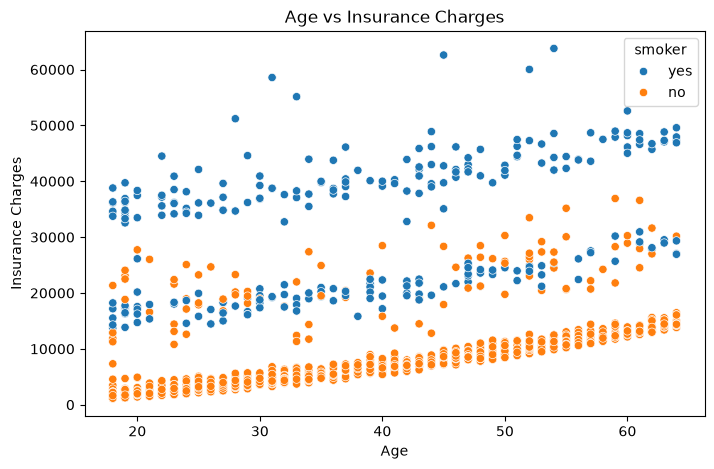

In [149]:
# age vs insurance charges
plt.figure(figsize=(8,5))

sns.scatterplot(x="age", y="charges", hue="smoker", data=df)

plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")

plt.show()

In [150]:
# Observations:
# • Insurance charges generally increase with age.
# • Smokers consistently have higher insurance charges than non-smokers across all age groups.
# • Older smokers tend to incur the highest insurance charges.
# • Smoking status strengthens the relationship between age and insurance charges.

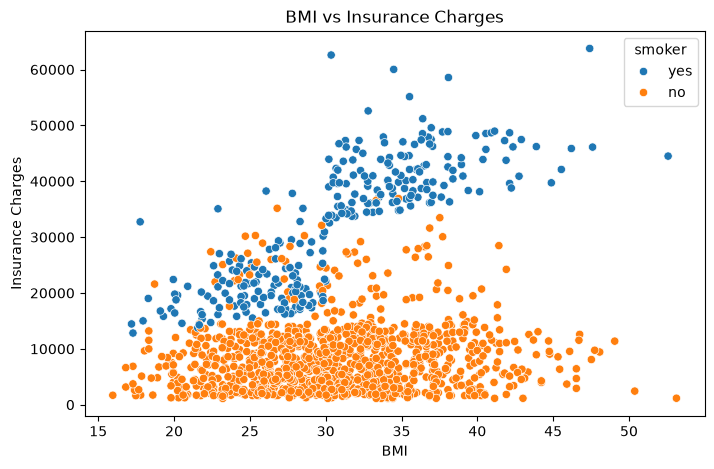

In [151]:
#bmi vs insurance charges
plt.figure(figsize=(8,5))

sns.scatterplot(x="bmi", y="charges",hue="smoker", data=df)

plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.show()

In [152]:
# Observations:
# • Insurance charges tend to increase with BMI.
# • Smokers with higher BMI generally incur the highest insurance charges.
# • Non-smokers mostly have lower insurance charges regardless of BMI.
# • BMI alone is not sufficient to explain insurance charges, as smoking status has a significant impact.

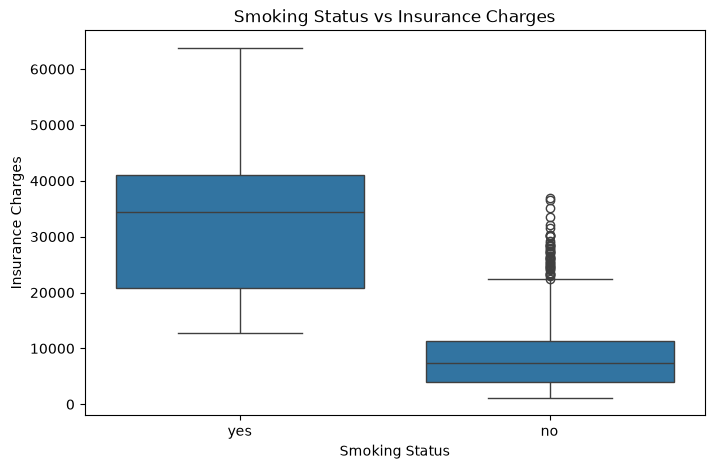

In [153]:
#smoking status vs insurance charges
plt.figure(figsize=(8,5))

sns.boxplot(x="smoker", y="charges", data=df)

plt.title("Smoking Status vs Insurance Charges")
plt.xlabel("Smoking Status")
plt.ylabel("Insurance Charges")

plt.show()

In [154]:
# Observations:
# • Smokers have significantly higher insurance charges than non-smokers.
# • The median insurance charge for smokers is substantially higher.
# • Smokers exhibit greater variability in insurance charges.
# • Smoking status appears to be the strongest predictor of insurance charges.

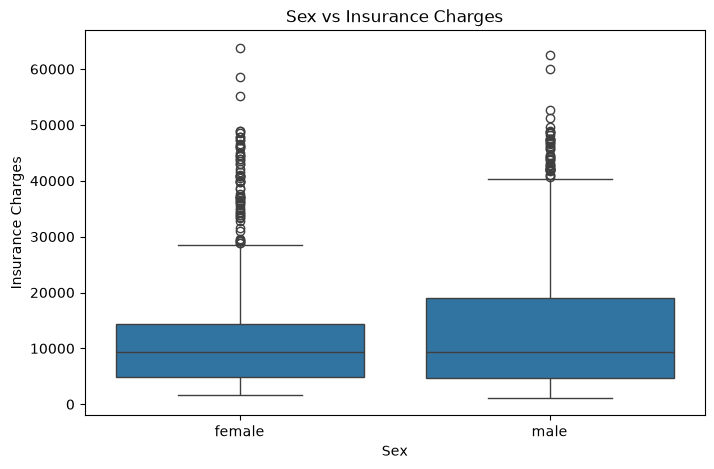

In [155]:
#sex vs insurance charges
plt.figure(figsize=(8,5))

sns.boxplot(x="sex", y="charges", data=df)

plt.title("Sex vs Insurance Charges")
plt.xlabel("Sex")
plt.ylabel("Insurance Charges")

plt.show()

In [156]:
# Observations:
# • Insurance charges are fairly similar for males and females.
# • The median charges for both groups are comparable.
# • Male policyholders show slightly greater variability.
# • Gender does not appear to significantly influence on insurance charges.

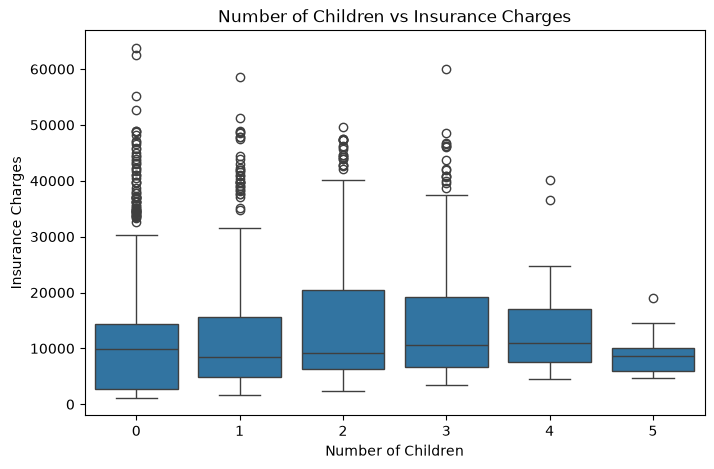

In [157]:
#children vs insurance charges
plt.figure(figsize=(8,5))

sns.boxplot(x="children", y="charges", data=df)

plt.title("Number of Children vs Insurance Charges")
plt.xlabel("Number of Children")
plt.ylabel("Insurance Charges")

plt.show()

In [158]:
# Observations:
# • Insurance charges show only a slight increase as the number of children increases.
# • Policyholders with 2-4 children tend to have slightly higher median charges.
# • Considerable variation exists within each category.
# • The number of children appears to have a weaker influence on insurance charges.

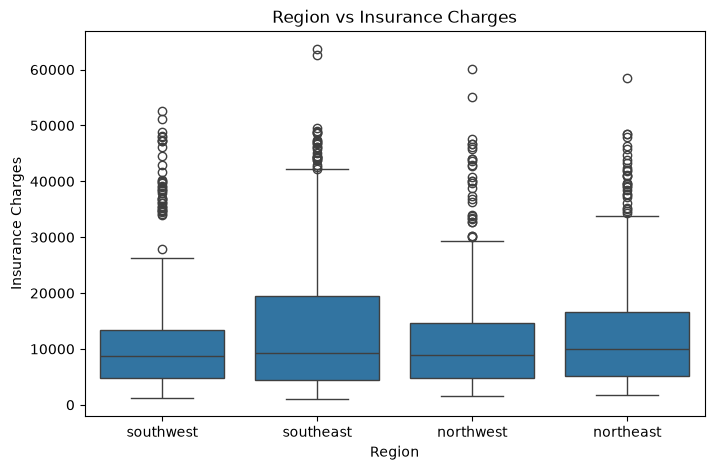

In [159]:
#region vs insurance charges
plt.figure(figsize=(8,5))

sns.boxplot(x="region", y="charges", data=df)

plt.title("Region vs Insurance Charges")
plt.xlabel("Region")
plt.ylabel("Insurance Charges")

plt.show()

In [160]:
# Observations:
# • Insurance charges are relatively similar across all regions.
# • The southeast region shows slightly higher variability in insurance charges.
# • All regions contain several high-cost outliers.
# • Region does not appear to strongly influence insurance charges.

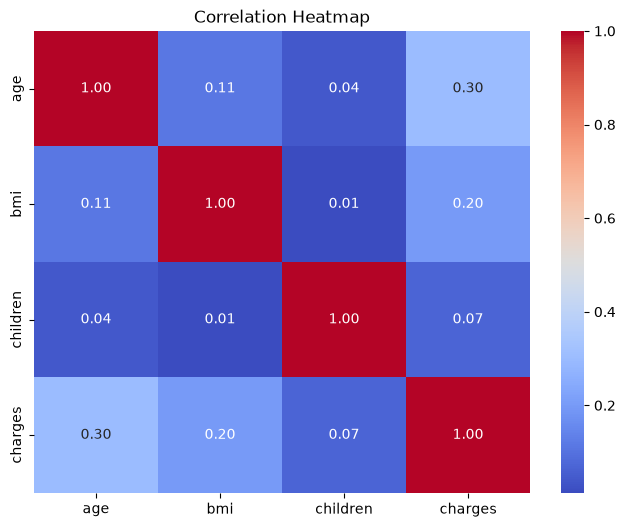

In [161]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

In [162]:
# Observations:
# • Age has the strongest positive correlation with insurance charges among the numerical variables.
# • BMI has a weak positive correlation with insurance charges.
# • Children have a very weak correlation with insurance charges.
# • The numerical variables show low correlation with one another, indicating low multicollinearity.

## Data Preprocessing

Preparing the dataset for machine learning by encoding categorical variables, selecting features, and splitting the data into training and testing sets.

In [163]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [164]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   bmi               1338 non-null   float64
 2   children          1338 non-null   int64  
 3   charges           1338 non-null   float64
 4   sex_male          1338 non-null   bool   
 5   smoker_yes        1338 non-null   bool   
 6   region_northwest  1338 non-null   bool   
 7   region_southeast  1338 non-null   bool   
 8   region_southwest  1338 non-null   bool   
dtypes: bool(5), float64(2), int64(2)
memory usage: 48.5 KB


In [165]:
X = df_encoded.drop("charges", axis=1)

y = df_encoded["charges"]

In [166]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (1338, 8)
Target: (1338,)


In [167]:
# Interpretation:
# • X contains the predictor variables.
# • y contains the target variable (insurance charges).

In [168]:
from sklearn.model_selection import train_test_split

In [169]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [170]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1070, 8)
(268, 8)
(1070,)
(268,)


In [171]:
# Interpretation:
# • 80% of the data will be used to train the model.
# • 20% will be used to evaluate model performance.
# • The random_state ensures reproducible results.

## Linear Regression Model

Linear Regression is a supervised machine learning algorithm used to predict a continuous numerical value. It serves as a baseline model for comparing the performance of more advanced algorithms.

In [172]:
from sklearn.linear_model import LinearRegression

In [173]:
lr_model = LinearRegression()

In [174]:
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 256.98, 337.09, 425.28,...,-370.68,-657.86,-809.8 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','bmi','children',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.193e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [175]:
y_pred = lr_model.predict(X_test)

In [176]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [177]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))

MAE : 4181.19
RMSE: 5796.28
R² Score: 0.7836


In [178]:
#Interpretation:
#• The model achieved an MAE of approximately 4181, meaning predictions differ from the actual insurance charges by about $4,181 on average.
#• The RMSE of 5796 indicates that larger prediction errors exist for some customers, particularly those with very high insurance charges.
#• The R² score of 0.7836 shows that the model explains approximately 78% of the variation in insurance charges, indicating good predictive performance for a baseline Linear Regression model.

In [179]:
results = pd.DataFrame({"Actual Charges": y_test,
    "Predicted Charges": y_pred})

results.head(10)

,Actual Charges,Predicted Charges
764,9095.06825,8969.550274
887,5272.17580,7068.747443
890,29330.98315,36858.410912
1293,9301.89355,9454.678501
259,33750.29180,26973.173457
1312,4536.25900,10864.113164
899,2117.33885,170.280841
752,14210.53595,16903.450287
1286,3732.62510,1092.430936
707,10264.44210,11218.343184


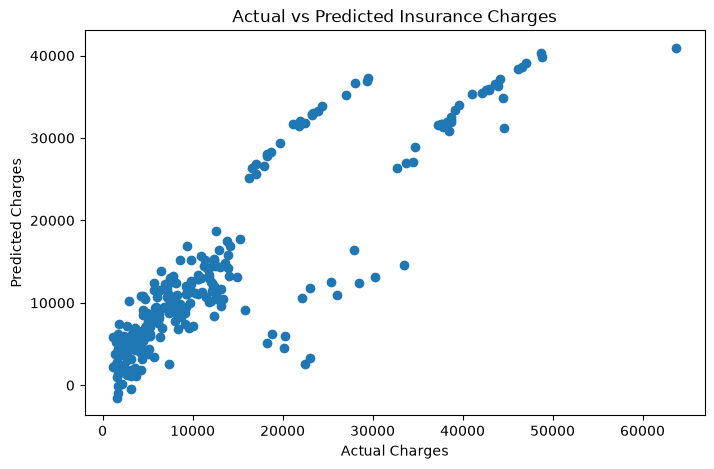

In [180]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")

plt.show()

In [181]:
# Observations:
# • Most predicted values follow the overall trend of the actual values.
# • Some high-cost insurance charges are harder for the model to predict accurately.
# • The model captures the general relationship but still exhibits prediction errors.

## Decision Tree Regression

A Decision Tree Regression model is built to capture non-linear relationships in the data and compare its performance with Linear Regression.

In [182]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [183]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = mean_squared_error(y_test, dt_pred) ** 0.5
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Results")
print("MAE :", round(dt_mae,2))
print("RMSE:", round(dt_rmse,2))
print("R² Score:", round(dt_r2,4))

Decision Tree Results
MAE : 3384.47
RMSE: 6861.24
R² Score: 0.6968


In [184]:
# Observation:
# The Decision Tree achieved an MAE of 3384.47 and an R² score of 0.6968.
# It has reduced the average prediction error compared to Linear Regression.
# However, the higher RMSE (6861.24) indicates that it made larger errors on some predictions.

## Random Forest Regression

A Random Forest Regression model is trained to improve prediction accuracy by combining multiple decision trees.

In [185]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [186]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", round(rf_mae,2))
print("RMSE:", round(rf_rmse,2))
print("R² Score:", round(rf_r2,4))

Random Forest Results
MAE : 2544.64
RMSE: 4573.55
R² Score: 0.8653


In [187]:
# Observation:
# Random Forest achieved the best performance with an MAE of 2544.64 and RMSE of 4573.55 
# This indicates that it predicts insurance charges more accurately
# It has an R^2 score of 0.8653 which implies it explains about 86.5% of the variation in the data.

## Model Comparison

The performance of all models is compared using MAE, RMSE and R² Score to identify the best-performing model.

In [188]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [mae, dt_mae, rf_mae],
    "RMSE": [rmse, dt_rmse, rf_rmse],
    "R² Score": [r2, dt_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,4181.194474,5796.284659,0.783593
1,Decision Tree,3384.473515,6861.241061,0.696766
2,Random Forest,2544.637064,4573.546074,0.865266


In [189]:
# Observation:
# Random Forest has the lowest MAE (2544.64), lowest RMSE (4573.55) and highest R² score (0.8653).
# Therefore, it outperformed both Linear Regression and Decision Tree.
# Linear Regression ranked second, while Decision Tree showed the weakest overall performance.

## Feature Importance

Feature importance is analyzed to identify which variables contribute the most to predicting insurance charges.

In [190]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,smoker_yes,0.608618
1,bmi,0.216701
0,age,0.134307
2,children,0.019301
3,sex_male,0.006279
5,region_northwest,0.005516
6,region_southeast,0.005335
7,region_southwest,0.003944


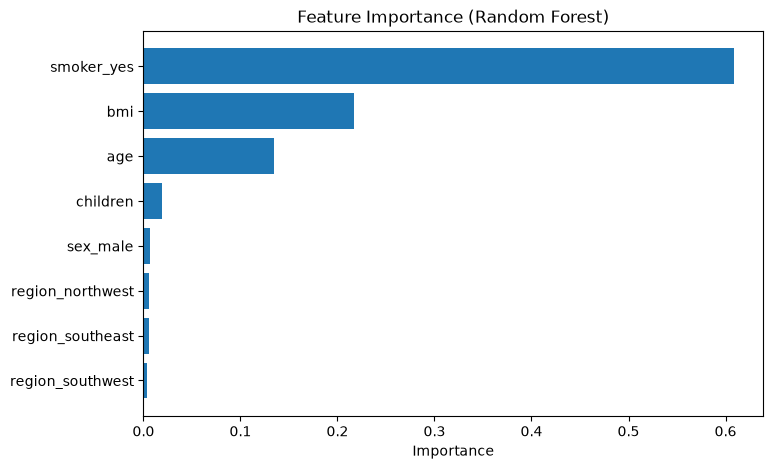

In [191]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()

plt.show()

In [192]:
# Observation:
# Smoking status was the most influential feature in predicting insurance charges, followed by BMI and age. 
# Other variables such as children, sex and region contributed comparatively less to the model's predictions.

## Saving the Trained Model

The trained Random Forest model is saved so that it can be reused for future predictions without retraining.

In [193]:
import joblib

# Save the trained Random Forest model
joblib.dump(rf, "../models/random_forest_model.pkl")

print("Model saved successfully!")

Model saved successfully!


## Conclusion

This project applied an end-to-end machine learning workflow to predict health insurance charges. By exploring the data, building multiple regression models, and comparing their performance, the project identified the most effective approach for accurate premium prediction. Overall, it demonstrates the practical application of machine learning in solving real-world predictive problems.